In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from cleantext import clean
import re
from tqdm import tqdm

from tensorflow.keras import backend as K

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)

In [ ]:
def apply_rope(x, sin, cos):
    """
    x   : (B, h, T, d) even-sized last dim (d must be multiple of 2)
    sin : (T, d//2)     broadcastable
    cos : (T, d//2)
    """
    #This separates each feature vector's dimensions into 2 halves — like real and imaginary parts.
    x_even = x[..., 0::2]      # Get even-dimension values → shape: (B, h, T, d/2)
    x_odd  = x[..., 1::2]      # Get odd-dimension values → shape: (B, h, T, d/2)

    # This is a 2D rotation formula applied to each positional index and head.
    # It "rotates" the embedding vector in its dimensional space based on position.
    x_rot_even =  x_even *  cos - x_odd * sin
    x_rot_odd  =  x_even *  sin + x_odd * cos
    
    # interleave even/odd back together
    x_rot = tf.stack([x_rot_even, x_rot_odd], axis=-1)   # (..., d/2, 2)
    return tf.reshape(x_rot, tf.shape(x))                # (..., d)

def make_sincos(seq_len, dim, base=10000):
    '''
    Returns sin, cos with shape (seq_len, dim//2)
    '''
    pos = tf.cast(tf.range(seq_len), tf.float32)                       # (T,)
    i   = tf.cast(tf.range(0, dim, 2), tf.float32) / dim              # (d/2,)
    theta = pos[:, None] / (base ** i[None, :])                       # (T, d/2)
    return tf.sin(theta), tf.cos(theta)

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    """
    Vanilla multi-head (scaled-dot-product) attention implemented from scratch.

    Args
    ----
    d_model     : int   – total embedding size (must be divisible by num_heads)  
    num_heads   : int   – number of attention heads  
    dropout     : float – dropout on attention weights (0.0 = no dropout)

    Call Signature
    --------------
    output, attn_scores = mha(
        query,                     # (B, T_q, d_model)
        value=None,                # (B, T_v, d_model)  – defaults to query
        key=None,                  # (B, T_k, d_model)  – defaults to value
        mask=None,                 # (B, 1, T_q, T_k) or (B, T_q, T_k)
        use_causal_mask=False,     # True → autoregressive causal mask
        training=None
    )
    """
    def __init__(self, d_model, num_heads, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0:
            raise ValueError(
                f"d_model={d_model} must be divisible by num_heads={num_heads}"
            )

        self.d_model   = d_model
        self.num_heads = num_heads
        self.depth     = d_model // num_heads

        # Linear projections for Q, K, V and final output
        self.wq   = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wk   = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wv   = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wo   = tf.keras.layers.Dense(d_model, use_bias=False)

        self.dropout = tf.keras.layers.Dropout(dropout)

    # ────────────────────────────────────────────────────────────────────────
    # Helpers
    # ────────────────────────────────────────────────────────────────────────
    def _split_heads(self, x, B):
        """
        Reshape (B, T, d_model) → (B, num_heads, T, depth)
        so we can run attention on each head in parallel.
        """
        x = tf.reshape(x, (B, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    @staticmethod
    def _scaled_dot_product_attention(q, k, v, mask, dropout,training=None):
        """
        Core attention: softmax(QKᵀ / √d_k) V
        Returns: (B, h, T_q, depth_v), (B, h, T_q, T_k)
        """
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(dk)  # (B,h,T_q,T_k)

        if mask is not None:
            # broadcast automatically if mask rank < scores rank
            scores += (mask * -1e9)  # large negative → zero probability

        attn = tf.nn.softmax(scores, axis=-1)
        attn = dropout(attn,training=training)
        output = tf.matmul(attn, v)  # (B,h,T_q,depth)
        return output

    # ────────────────────────────────────────────────────────────────────────
    # Forward pass
    # ────────────────────────────────────────────────────────────────────────
    def call(
        self,
        query,
        value=None,
        key=None,
        mask=None,
        use_causal_mask=False,
        training=None
    ):
        if value is None:
            value = query
        if key is None:
            key = value

        B = tf.shape(query)[0]
        Tq = tf.shape(query)[1]          # sequence length of Q
        Tk = tf.shape(key)[1]

        # 1. Linear projections
        q = self.wq(query)   # (B, T_q, d_model)
        k = self.wk(key)     # (B, T_k, d_model)
        v = self.wv(value)   # (B, T_v, d_model)

        # 2. Reshape for multi-head
        q = self._split_heads(q, B)  # (B, h, T_q, depth)
        k = self._split_heads(k, B)  # (B, h, T_k, depth)
        v = self._split_heads(v, B)  # (B, h, T_v, depth)

        # 3) -----------------  ROTARY  -----------------
        # Build sin/cos for the longest sequence we need this step
        max_len = tf.maximum(Tq, Tk)
        sin, cos = make_sincos(max_len, self.depth)       # depth = d_model / num_heads

        # Slice sin/cos to actual lengths (broadcast works automatically)
        # RoPE modifies Q and K such that their dot product reflects not just content similarity but also relative position.
        q = apply_rope(q, sin[:Tq], cos[:Tq])             # rotate Q
        k = apply_rope(k, sin[:Tk], cos[:Tk])             # rotate K
        # ----------------------------------------------

        # 3. (Optional) Causal mask: block future positions
        if use_causal_mask:
            T_q = tf.shape(q)[2]
            T_k = tf.shape(k)[2]
            causal = 1.0 - tf.linalg.band_part(tf.ones((T_q, T_k)), -1, 0)  # lower-tri  # 1 → masked
            causal = causal[tf.newaxis, tf.newaxis, :, :]  # (1,1,T_q,T_k)
            mask = causal if mask is None else tf.maximum(mask, causal)

        # 4. Scaled dot-product attention
        attn_out = self._scaled_dot_product_attention(
            q, k, v, mask, self.dropout,training=training,
        )  # (B,h,T_q,depth), (B,h,T_q,T_k)

        # 5. Concatenate heads
        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])  # (B,T_q,h,depth)
        attn_out = tf.reshape(attn_out, (B, -1, self.d_model))  # (B,T_q,d_model)

        # 6. Final linear layer
        output = self.wo(attn_out)  # (B,T_q,d_model)

        return output
    
class RMSNorm(tf.keras.layers.Layer):
    def __init__(self, hidden_size, epsilon=1e-8, **kwargs):
        super(RMSNorm, self).__init__(**kwargs)
        self.hidden_size = hidden_size
        self.epsilon = epsilon
        
        # Learnable scale parameter γ (same shape as last dim of input)
        self.scale = self.add_weight(
            name="scale",
            shape=(self.hidden_size,),
            initializer="ones",
            trainable=True
        )

    def call(self, x):
        rms = tf.sqrt(tf.reduce_mean(tf.square(x), axis=-1, keepdims=True) + self.epsilon)
        norm_x = x / rms
        return norm_x * self.scale

class CausalSelfAttention(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        self.mha = MultiHeadAttention(d_model=d_model,
                                      num_heads=num_heads,
                                      dropout=dropout)
        self.rmsnorm = RMSNorm(d_model)
        self.add = tf.keras.layers.Add()

    def call(self, x, padding_mask=None, training=None):

        rms_x1 = self.rmsnorm(x)

        attn_output = self.mha(
            query=rms_x1, value=rms_x1, key=rms_x1,
            mask=padding_mask,          # may be None
            use_causal_mask=True,
            training=training,
        )
        rms_x1 = self.add([x, attn_output])
        return rms_x1

In [ ]:
class SwiGLU(tf.keras.layers.Layer):
    def __init__(self, hidden_dim,factor=4):
        super().__init__()
        self.lin1 = tf.keras.layers.Dense(factor*hidden_dim,use_bias=False)   # W1
        self.lin2 = tf.keras.layers.Dense(hidden_dim,use_bias=False)       # W2

    def call(self, x):
        x_ = self.lin1(x)                          # shape: (..., 4d)
        a, b = tf.split(x_, num_or_size_splits=2, axis=-1)  # split
        gated = a * (b * tf.sigmoid(b))            # SwiGLU: a ⊙ SiLU(b)
        return self.lin2(gated)

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dropout_rate=0.1):
        super().__init__()

        self.seq = tf.keras.Sequential(
            [
                SwiGLU(d_model),
                tf.keras.layers.Dropout(dropout_rate),
            ]
        )
        self.rmsnorm = RMSNorm(d_model)

    def call(self, x, training=None):
        y = self.seq(self.rmsnorm(x), training=training)  # pre-norm
        return x + y                                  # residual on raw x
    
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dropout_rate=0.1):
        super().__init__()
        self.causal_self_attention = CausalSelfAttention(num_heads=num_heads, d_model=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model)

    def call(self, x, padding_mask=None, training=None):
        x = self.causal_self_attention(x, padding_mask=padding_mask, training=training)
        x = self.ffn(x,training=training)
        return x

In [ ]:
# To define the Transformer decoder in TensorFlow you need:
#          1. The positional embedding layer
#          2. A stack of decoder layers

class TokenEmbedding(tf.keras.layers.Layer):
    """
    
    Args:
        vocab_size (int): Vocabulary size (number of unique tokens).
        d_model (int): Embedding dimension.
    """
    def __init__(self, vocab_size, d_model):
        super().__init__()

        # Learnable token embeddings
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size, 
            output_dim=d_model, 
            mask_zero=True  # Ensures padding token is masked
        )

    def compute_mask(self, *args, **kwargs):
        # Pass through the mask from the embedding layer
        return self.embedding.compute_mask(*args, **kwargs)

    def call(self, x):
        """
        Args:
            x: Tensor of token indices → shape: (batch_size, sequence_length)
        
        Returns:
            Tensor of shape (batch_size, sequence_length, d_model)
        """

        # Convert token indices to dense vectors → (batch_size, seq_len, d_model)
        x = self.embedding(x)

        return x

class Decoder(tf.keras.layers.Layer):
    def __init__(
        self, *, num_layers, d_model, num_heads, vocab_size, dropout_rate=0.1
    ):
        super(Decoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.pos_embedding = TokenEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        
        self.dec_layers = [DecoderLayer(d_model=d_model, num_heads=num_heads, dropout_rate=dropout_rate)
                           for _ in range(num_layers)]

        self.last_attn_scores = None

    def call(self, x, training=None):
        pad_mask = self.pos_embedding.compute_mask(x)
        if pad_mask is not None:
            pad_mask = tf.cast(~pad_mask, tf.float32)[:, tf.newaxis, tf.newaxis, :]

        x = self.pos_embedding(x)
        x = self.dropout(x, training=training)

        for layer in self.dec_layers:
            x = layer(x, padding_mask=pad_mask, training=training)

        return x
    

class Transformer(tf.keras.Model):
    def __init__(self, *, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()

        self.decoder = Decoder(
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            vocab_size=input_vocab_size,
            dropout_rate=dropout_rate,
        )

        self.rmsnorm = RMSNorm(d_model)
        self.final_layer = tf.keras.layers.Dense(input_vocab_size)

    def call(self, inputs,training=False):
        # To use a Keras model with `.fit` you must pass all your inputs in the
        # first argument.
        x = inputs

        x = self.decoder(x,training=training)  # (batch_size, target_len, d_model)

        # Final linear layer output.
        x = self.rmsnorm(x)
        logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

        try:
            # Drop the keras mask, so it doesn't scale the losses/metrics.
            # b/250038731
            del logits._keras_mask
        except AttributeError:
            pass

        # Return the final output and the attention weights.
        return logits

In [5]:
df1 = pd.read_excel("Inshorts Cleaned Data.xlsx").dropna(subset=['Headline','Short']).rename(columns={'Headline':'target_txt','Short':'input_txt'})[['target_txt','input_txt']]
df2 = pd.read_csv('train.csv').rename(columns={'dialogue':'input_txt','summary':'target_txt'})[['target_txt','input_txt']]
df3 = pd.read_json('train.json').rename(columns={'dialogue':'input_txt','summary':'target_txt'})[['target_txt','input_txt']]
#df4 = pd.read_csv('cnn.csv').rename(columns={'article':'input_txt','highlights':'target_txt'})[['target_txt','input_txt']]

train_df = pd.concat([df1,df2,df3]).reset_index(drop=True)
train_df

,target_txt,input_txt
0,4 ex-bank officials booked for cheating bank o...,The CBI on Saturday booked four former officia...
1,Supreme Court to go paperless in 6 months: CJI,Chief Justice JS Khehar has said the Supreme C...
2,"At least 3 killed, 30 injured in blast in Sylh...","At least three people were killed, including a..."
3,Why has Reliance been barred from trading in f...,Mukesh Ambani-led Reliance Industries (RIL) wa...
4,Was stopped from entering my own studio at Tim...,TV news anchor Arnab Goswami has said he was t...
...,...,...
82291,Romeo is trying to get Greta to add him to her...,Romeo: You are on my ‘People you may know’ lis...
82292,Theresa is at work. She gets free food and fre...,Theresa: <file_photo>\r\nTheresa: <file_photo>...
82293,Japan is going to hunt whales again. Island an...,John: Every day some bad news. Japan will hunt...
82294,Celia couldn't make it to the afternoon with t...,Jennifer: Dear Celia! How are you doing?\r\nJe...


In [6]:
# 1) Text cleaning ------------------------------------------------------
def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    try:
        # text = text.lower()
        text = re.sub(r'[^a-zA-Z0-9.,!?]+', ' ', text)
        text = text.replace('\r', ' ').replace('\n', ' ')
        text = re.sub(r'\s+', ' ', text)
        return text.strip().lower()
    except:
        return text

train_df['target_txt'] = train_df['target_txt'].apply(lambda x: clean_text(x))
train_df['input_txt'] = train_df['input_txt'].apply(lambda x: clean_text(x))

In [7]:
import numpy as np
from tqdm.auto import tqdm

# Combine summary + dialogue and split on whitespace
raw_lens = [
    len(f"{s} {d}".split()) 
    for s, d in tqdm(zip(train_df["target_txt"], train_df["input_txt"]), total=len(train_df))
]

lens = np.array(raw_lens)

# Print summary stats
def pct(x): return np.percentile(lens, x)

print(f"Total examples    : {len(lens):,}")
print(f"Min / Max words   : {lens.min()} / {lens.max()}")
print(f"Mean ± std        : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- Percentiles (word count per raw text pair) ---")
for p in [50, 90, 95, 98, 99]:
    print(f"{p:>3}% : {pct(p):.0f} words")

/Users/saptarshimallikthakur/Desktop/Extraas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 82296/82296 [00:00<00:00, 335684.31it/s]

Total examples    : 82,296
Min / Max words   : 6 / 1164
Mean ± std        : 93.4 ± 58.7
--- Percentiles (word count per raw text pair) ---
 50% : 73 words
 90% : 164 words
 95% : 218 words
 98% : 284 words
 99% : 330 words


In [8]:
MAX_LEN = int(pct(90))

text_pairs = []

for i,j in zip(train_df.input_txt,train_df.target_txt):
    try:
        if len(i.split(" ")+j.split(" ")) < MAX_LEN:       # BOS, SEP,EOS extra
            text_pairs.append((i,j))
    except:
        pass

len(text_pairs),text_pairs[:5]

(73988,
 [('the cbi on saturday booked four former officials of syndicate bank and six others for cheating, forgery, criminal conspiracy and causing 209 crore loss to the state run bank. the accused had availed home loans and credit from syndicate bank on the basis of forged and fabricated documents. these funds were fraudulently transferred to the companies owned by the accused persons.',
   '4 ex bank officials booked for cheating bank of 209 crore'),
  ('chief justice js khehar has said the supreme court will go paperless in six to seven months in a bid to save funds and make the judiciary eco friendly. he further said the apex court will collect all the records electronically from the lower courts and the high courts so that there is no need to file hard copies.',
   'supreme court to go paperless in 6 months cji'),
  ('at least three people were killed, including a policeman, while 30 others were wounded on saturday evening in two explosions in sylhet, bangladesh. the explosions w

In [9]:
train_df = pd.DataFrame(text_pairs).rename(columns={0:'input_txt',1:'target_txt'})

1000



2000



3000



4000



6000



8000



10000



12000



16000



20000





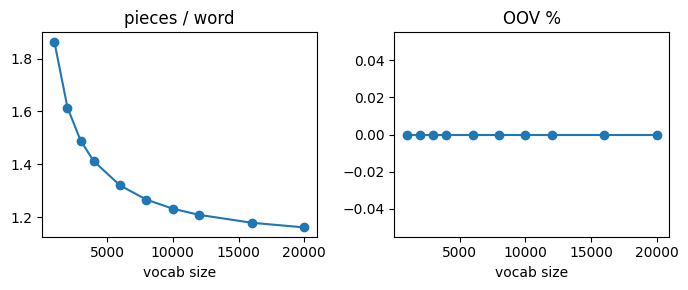

In [10]:
import numpy as np
import pandas as pd
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
import matplotlib.pyplot as plt

# ── assume train_df already loaded ─────────────────────────────────────
rng            = np.random.default_rng(42)
valid_mask     = rng.random(len(train_df)) < 0.05          # 5 % hold-out
train_df_, valid_df = train_df[~valid_mask], train_df[valid_mask]

# ⇢ cache validation texts so we can loop over them many times
valid_texts = [f"{s} {d}" for s, d in
               zip(valid_df["target_txt"], valid_df["input_txt"])]

def train_tokenizer(text_iter, vocab_size: int) -> Tokenizer:
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size,
                                  min_frequency=2,
                                  special_tokens=["[UNK]"])
    tok.train_from_iterator(text_iter, trainer)
    return tok

def avg_pieces_per_word(tok: Tokenizer, texts) -> float:
    pieces = words = 0
    for t in texts:
        ids   = tok.encode(t).ids
        pieces += len(ids)
        words  += len(t.split())
    return pieces / words

vocab_sizes = [1000,2000,3000,4000,6000,8000,10000,12000,16000,20000]
pieces_per_word, oov_rate = [], []

for k in vocab_sizes:
    print(k)
    train_iter = (f"{s} {d}" for s, d in
                  zip(train_df_["target_txt"], train_df_["input_txt"]))
    tok = train_tokenizer(train_iter, k)

    # 1) average sub-words per word on validation set
    pieces_per_word.append(avg_pieces_per_word(tok, valid_texts))

    # 2) OOV percentage on validation set
    unk_id = tok.token_to_id("[UNK]")
    total = unk = 0
    for t in valid_texts:
        ids   = tok.encode(t).ids
        total += len(ids)
        unk   += sum(id_ == unk_id for id_ in ids)
    oov_rate.append(100 * unk / total)

# ── plot ───────────────────────────────────────────────────────────────
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.plot(vocab_sizes, pieces_per_word, marker='o')
plt.title("pieces / word"); plt.xlabel("vocab size")

plt.subplot(1,2,2)
plt.plot(vocab_sizes, oov_rate, marker='o')
plt.title("OOV %"); plt.xlabel("vocab size")

plt.tight_layout(); plt.show()

In [11]:
VOCAB_SIZE = 4000

CORPUS_FILE = 'all_texts.txt'
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[BOS]', '[EOS]','[SEP]']

with open(CORPUS_FILE, 'w', encoding='utf-8') as f:
    for _, row in train_df.iterrows():
        f.write(str(row['target_txt']) + ' ' + str(row['input_txt']) + '\n')

In [12]:
import re
import pandas as pd
import tensorflow as tf
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers.processors import TemplateProcessing

# Initialize and train
tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=VOCAB_SIZE, special_tokens=SPECIAL_TOKENS)
tokenizer.train([CORPUS_FILE], trainer)

# 3) Configure post-processing, padding & truncation ------------------
pad_id = tokenizer.token_to_id('[PAD]')
unk_id = tokenizer.token_to_id('[UNK]')
bos_id = tokenizer.token_to_id('[BOS]')
eos_id = tokenizer.token_to_id('[EOS]')
sep_id = tokenizer.token_to_id('[SEP]')

# Add BOS/EOS around single sequences
tokenizer.post_processor = TemplateProcessing(
    single='[BOS] $A [SEP]',
    pair='[BOS] $A [SEP] $B [EOS]',
    special_tokens=[('[BOS]', bos_id), ('[EOS]', eos_id),('[SEP]', sep_id)],
)

100%|██████████| 73988/73988 [00:07<00:00, 10556.69it/s]


Total samples    : 73,988
Min / Max tokens : 11 / 368
Mean ± std       : 110.5 ± 29.4
--- percentiles (tokens) ---
 50% : 106
 90% : 145
 95% : 178
 98% : 202
 99% : 214


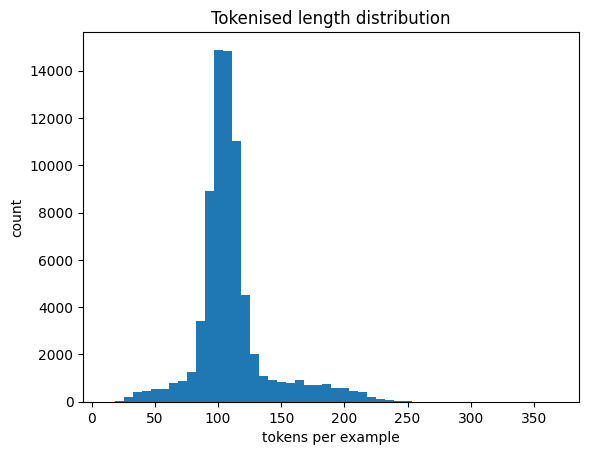

In [13]:
# ------------------------------------------------------------
# 0)  Make sure `tok` points to the FINAL tokenizer
#     → trained on the full corpus with your chosen vocab_size
# ------------------------------------------------------------
tok = tokenizer          # whatever variable you use

# ------------------------------------------------------------
# 1)  Get token counts for every example
#     (here: concatenate summary + dialogue; split if you want)
# ------------------------------------------------------------
lens = []

for s, d in tqdm(zip(train_df["target_txt"], train_df["input_txt"]),
                 total=len(train_df)):
    txt   = f"{s} {d}"
    ids   = tok.encode(txt).ids
    lens.append(len(ids))

lens = np.array(lens)

# ------------------------------------------------------------
# 2)  Print key stats
# ------------------------------------------------------------
def pct(x): return np.percentile(lens, x)

print(f"Total samples    : {len(lens):,}")
print(f"Min / Max tokens : {lens.min()} / {lens.max()}")
print(f"Mean ± std       : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- percentiles (tokens) ---")
for p in (50, 90, 95, 98, 99):
    print(f"{p:>3}% : {pct(p):.0f}")

# ------------------------------------------------------------
# 3)  Quick histogram    (no seaborn, single plot, no colors set)
# ------------------------------------------------------------
plt.hist(lens, bins=50)
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.title("Tokenised length distribution")
plt.show()

In [14]:
BATCH_SIZE = 32
MAX_LEN = int(pct(p))

In [15]:
# 0) Configure your tokenizer *once* at startup, not per-example
tokenizer.enable_truncation(
    max_length=MAX_LEN
)

tokenizer.enable_padding(
    pad_id=pad_id,
    pad_token='[PAD]',
    length=MAX_LEN
)

def encode_text(texts, max_length=MAX_LEN):
    encodings = tokenizer.encode(texts)
    return np.array(encodings.ids, dtype=np.int32)

# 1) encode_pair → return a NumPy array
def encode_pair(text_a: str, text_b: str) -> np.ndarray:
    enc = tokenizer.encode(text_a, text_b)
    return np.array(enc.ids, dtype=np.int32)   # shape: [MAX_LEN]

def encode_example(text: str, summary: str):
    ids = encode_pair(text, summary)           # np.ndarray, shape=[MAX_LEN]
    labels = np.concatenate([ids[1:], [pad_id]])  # shape=[MAX_LEN]

    # find SEP
    sep_idxs = np.where(labels == sep_id)[0]
    sep_pos = int(sep_idxs[0]) if sep_idxs.size else len(ids)

    # build base mask: 1 only for positions > sep_pos AND not PAD
    positions = np.arange(len(labels))
    base_mask = (positions > sep_pos).astype(np.float32) * (labels != pad_id).astype(np.float32)

    return ids, labels.astype(np.int32), base_mask

# ── 0. do *all* tokenisation once ──────────────────────────
triples = [encode_example(t, s) for (t, s) in text_pairs]   # Python loop, done **once**
ids, labels, masks = map(lambda k: tf.constant(np.stack(k, 0)),
                         zip(*triples))                      # shapes [N, MAX_LEN]

# ── 1. build the purely-TF dataset ─────────────────────────
ds = (
    tf.data.Dataset.from_tensor_slices(
        {"input_ids": ids, "labels": labels, "loss_mask": masks}
    )
    .shuffle(len(text_pairs))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

2025-06-03 20:27:59.206387: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-06-03 20:27:59.206416: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-06-03 20:27:59.206420: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-06-03 20:27:59.206435: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-03 20:27:59.206447: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [16]:
vocab = tokenizer.get_vocab()           # indices 0 … V

id_to_token = {idx: tok for tok, idx in vocab.items()}

# 2) Decoder: drop PADs, replace unknown IDs with '?'
def decode_token_ids(token_ids: list[int]) -> str:
    tokens = []
    for tid in token_ids:
        if tid == pad_id:
            continue
        tokens.append(id_to_token.get(tid, '?'))
    return ' '.join(tokens)

# 3) Inspect one batch from your TF dataset
for batch in ds.take(10):
    input_ids = batch['input_ids'].numpy()  # shape (batch, MAX_LEN)
    labels    = batch['labels'].numpy()
    loss_mask = batch["loss_mask"].numpy()

    for i, (ids_row, lbl_row) in enumerate(zip(input_ids, labels), start=1):
        print(f"\n🟢 Sample {i}")
        print("  Input IDs: ", ids_row.tolist())
        print("  Decoded:   ", decode_token_ids(ids_row.tolist()))
        print("  Label IDs: ", lbl_row.tolist())


🟢 Sample 1
  Input IDs:  [2, 886, 1332, 725, 3986, 48, 649, 1675, 19, 751, 1923, 70, 12, 1360, 665, 83, 50, 1768, 873, 1703, 6, 62, 414, 19, 1923, 70, 1570, 665, 46, 50, 215, 1377, 2016, 7, 1075, 6, 50, 554, 73, 37, 1509, 2654, 2065, 13, 7, 10, 215, 48, 215, 60, 9, 7, 2417, 825, 7, 25, 1081, 791, 2654, 143, 657, 1061, 6, 379, 2654, 175, 50, 1332, 73, 37, 1941, 1754, 1181, 65, 827, 1537, 6, 539, 6, 67, 1543, 2442, 1489, 2065, 985, 7, 15, 7, 4, 725, 3986, 3618, 751, 1923, 70, 12, 1360, 2862, 46, 1703, 1768, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Decoded:    [BOS] tech firm ya hoo on monday reported a net loss of 4 40 million for the quarter ended june , as against a loss of 22 million in th

2025-06-03 20:27:59.521689: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
j=0
print(batch["loss_mask"][j].numpy())
print('\n',decode_token_ids(batch["input_ids"][j].numpy()))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

 [BOS] actor amit abh bachchan has conf ess ed that he still gets 34 sle e pl ess n ights 34 and 34 an x i ety 34 before 34 each shot that needs to be taken 39 39 . 34 every film is a test , an exam ination for me ... that is the way i would like it to be . nothing comes easy in life . certainly not a hard hit ting film , 34 added bachchan . [SE

In [18]:
num_layers = 2
d_model = 256
num_heads = 8  # 32 dim per head
dropout_rate = 0.1

model = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=VOCAB_SIZE,
    dropout_rate=dropout_rate
)

# assume MAX_LEN is your sequence length
dummy = tf.zeros((1, MAX_LEN), dtype=tf.int64)
_ = model(dummy)      # this builds all the weights
model.summary()

/Users/saptarshimallikthakur/Desktop/Extraas/lib/python3.12/site-packages/keras/src/layers/layer.py:939: UserWarning: Layer 'rms_norm' (of type RMSNorm) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/saptarshimallikthakur/Desktop/Extraas/lib/python3.12/site-packages/keras/src/layers/layer.py:939: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/saptarshimallikthakur/Desktop/Extraas/lib/python3.12/site-packages/keras/src/layers/layer.py:939: UserWarning: Layer 'decoder_layer' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will ther

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder (Decoder)               │ ?                      │     2,335,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rms_norm_4 (RMSNorm)            │ ?                      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (1, 214, 4000)         │     1,028,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,364,000 (12.83 MB)

 Trainable params: 3,364,000 (12.83 MB)

 Non-trainable params: 0 (0.00 B)

tf.Tensor(
[1.000000e-06 1.000000e-06 1.000000e-06 ... 7.943662e-06 7.942890e-06
 7.942117e-06], shape=(46242,), dtype=float32)


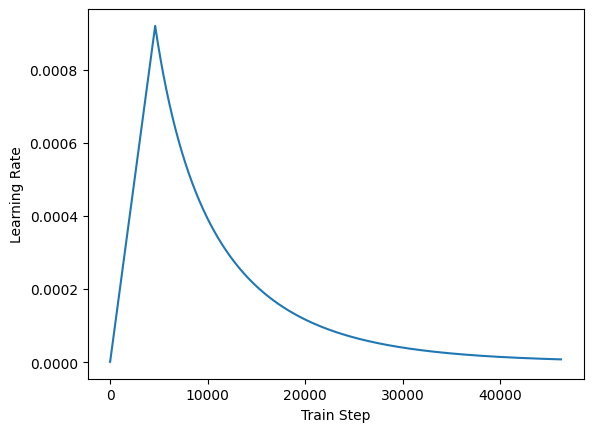

In [19]:
WARM_FRAC   = 0.1      # keep the fast ramp-up
DECAY_RATE  = 4
LR_FLOOR    = 1e-6
LR_PEAK_DESIRED = 8e-4     # choose 8e-4 or 9e-4
EPOCHS = 20

# pre-compute the scale that gives that peak
num_steps     = EPOCHS * len(text_pairs) // BATCH_SIZE
warmup_steps  = int(num_steps * WARM_FRAC)
current_peak  = 1.0 / tf.sqrt(tf.cast(d_model * warmup_steps, tf.float32))
LR_SCALE      = LR_PEAK_DESIRED / current_peak.numpy()

@tf.keras.utils.register_keras_serializable()   # so it can round-trip in SavedModel/H5
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, total_steps=num_steps,
                 warmup_frac=WARM_FRAC, decay_rate=DECAY_RATE,
                 lr_scale=LR_SCALE):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(int(total_steps * warmup_frac), tf.float32)
        self.decay_rate   = decay_rate
        self.decay_steps  = tf.cast(total_steps, tf.float32)
        # self.lr_scale     = tf.cast(lr_scale, tf.float32)

    def __call__(self, step):
        step  = tf.cast(step, tf.float32)
        arg1  = tf.math.rsqrt(step)
        arg2  = step * tf.math.pow(self.warmup_steps, -1.5)
        warm  = tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)
        decay = tf.math.exp(-self.decay_rate *
                            tf.maximum(step - self.warmup_steps, 0.) /
                            self.decay_steps)
        lr = warm * decay #* self.lr_scale 
        return tf.maximum(lr, LR_FLOOR)

    # ----------  NEW  ----------
    def get_config(self):
        return {
            "d_model":      int(self.d_model.numpy()),   # cast back to Python types
            "total_steps":  int(self.decay_steps.numpy()),
            "warmup_frac":  float(self.warmup_steps.numpy() / self.decay_steps.numpy()),
            "decay_rate":   self.decay_rate,
            # "lr_scale":     float(self.lr_scale.numpy()),
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)
    
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9, clipnorm=1.0)
    
temp_learning_rate_schedule = CustomSchedule(d_model)

plt.plot(temp_learning_rate_schedule(tf.range(num_steps, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

print(temp_learning_rate_schedule(tf.range(num_steps, dtype=tf.float32)))

In [20]:
# 2) Repack your dataset for .fit()
# Each element becomes (x, y, sample_weight)
ds_for_fit = ds.map(lambda b: (           # ds originally yields dicts
    b["input_ids"],        # x
    b["labels"],           # y_true
    b["loss_mask"]         # sample_weight: 1.0 on summary tokens, 0 elsewhere
))

# 3) Compile with a standard sparse‐CE loss and let Keras use sample weights
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none"),
    metrics=["sparse_categorical_accuracy"]
)

# Model's output (logits) is: logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size).
# This is a tensor of logits, where for each position in the sequence, you have a score for every possible token in your vocabulary.
# Because labels are integer token IDs (e.g., [10, 54, 3, 0, 0]) and not one-hot encoded vectors (e.g., [[0..1..0], [0..1..0], ...]), SparseCategoricalAccuracy is the appropriate metric. 
# It correctly compares the integer label at each timestep with the class that has the highest logit output by the model for that timestep.

# Build callbacks
callbacks = [
    EarlyStopping(monitor="loss", patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        filepath="best_summary.keras",        # or "best_summary.h5"
        monitor="loss",
        save_best_only=True,
        verbose=1             # full model (weights + optimizer + LR schedule)
    )
]

# 4) Fit!  Keras will print epoch/step progress by default
history = model.fit(
    ds_for_fit,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1    # 1 = progress bar, loss & acc per epoch
)

Epoch 1/20


2025-06-03 17:07:28.547068: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2313/2313 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 0.5447 - sparse_categorical_accuracy: 0.0128
Epoch 1: loss improved from inf to 0.48176, saving model to best_summary.keras
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 475s 204ms/step - loss: 0.5447 - sparse_categorical_accuracy: 0.0128
Epoch 2/20
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.3736 - sparse_categorical_accuracy: 0.0387
Epoch 2: loss improved from 0.48176 to 0.35755, saving model to best_summary.keras
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 452s 195ms/step - loss: 0.3736 - sparse_categorical_accuracy: 0.0387
Epoch 3/20
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.3092 - sparse_categorical_accuracy: 0.0495
Epoch 3: loss improved from 0.35755 to 0.30344, saving model to best_summary.keras
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 458s 198ms/step - loss: 0.3092 - sparse_categorical_accuracy: 0.0495
Epoch 4/20
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.2653 - sparse_categorical_accuracy: 0.0571
Epoch 4: loss improved from 0.

In [20]:
def encode_dialogue(text: str, max_len: int = MAX_LEN) -> tf.Tensor:
    """
    Returns [BOS] dialogue [EOS] *without* any padding.
    """
    tokenizer.no_padding()                         # turn padding off
    tokenizer.enable_truncation(max_length=max_len)
    ids = tokenizer.encode(text).ids               # already BOS/EOS
    return tf.constant(ids, tf.int32)              # 1-D tensor


def generate_summary(
    dialogue_ids: tf.Tensor,        # [BOS] … [EOS]  (no pads)
    model: tf.keras.Model,
    max_new: int = 120,
    temperature: float = 0.1
) -> tf.Tensor:
    """
    Produce [BOS] dialogue [SEP] summary … [EOS]
    """
    prompt = tf.concat([dialogue_ids[:-1], [sep_id]], 0)[None, :]  # add batch dim

    for _ in range(max_new):
        if prompt.shape[1] > MAX_LEN:                # keep within PE range
            break

        logits  = model.predict(prompt,verbose=False)[:, -1, :] / temperature
        next_id = tf.random.categorical(logits, 1, dtype=tf.int32)
        prompt  = tf.concat([prompt, next_id], 1)

        if next_id[0, 0] == eos_id:
            break

    return tf.squeeze(prompt, 0)

def display_text_and_summary(dialogue: str, target: str, model):
    """
    Given a raw dialogue string and a summary model, this function:
      1. Encodes the dialogue into token IDs.
      2. Generates [BOS] dialogue [SEP] summary [EOS].
      3. Splits at [SEP], decodes each part, and prints:
         - "Text: <original dialogue…>"
         - "Summary: <generated summary…>"
    """
    # 1. Encode the dialogue (adds [BOS] … [EOS])
    dlg_ids = encode_dialogue(clean_text(dialogue))

    # 2. Generate the full sequence [BOS] dialogue [SEP] summary [EOS]
    full_ids = generate_summary(dlg_ids, model)

    # 3. Convert to a plain Python list so we can find sep_id
    full_ids_list = full_ids.numpy().tolist()

    # 4. Find the position of sep_id
    sep_index = full_ids_list.index(sep_id)

    # 5. Split into dialogue_part and summary_part
    dialogue_part = full_ids_list[:sep_index]
    summary_part  = full_ids_list[sep_index + 1:]  # skip the sep_id itself

    # 6. Decode each slice
    text_str    = decode_token_ids(dialogue_part)
    summary_str = decode_token_ids(summary_part)

    # 7. Print on two lines
    print("\n Text:", text_str)
    print("\n Genrated Summary:", summary_str)
    print("\n Original Summary:", target)

In [29]:
for j in range(10):
    print(j)
    dialogue = df1['input_txt'][j]
    summary = df1['target_txt'][j]
    display_text_and_summary(dialogue, summary, model)
    print('----------------')

0

 Text: [BOS] the cbi on saturday booked four former officials of sy nd ic ate bank and six others for che ating , for ger y , criminal con spir acy and ca using 20 9 crore loss to the state run bank . the accused had avail ed home lo ans and credit from sy nd ic ate bank on the bas is of for ged and f ab ric ated documents . these funds were fra ud ul ent ly transfer red to the companies owned by the accused person s .

 Genrated Summary: 4 ex officials booked for che ating bank officials [EOS]

 Original Summary: 4 ex-bank officials booked for cheating bank of ₹209 crore
----------------
1

 Text: [BOS] chief justice j s k he har has said the supreme court will go paper less in six to seven months in a bid to save funds and make the jud ic i ary e co friend ly . he further said the ap ex court will colle ct all the records electron ically from the lower cour ts and the high cour ts so that there is no need to file hard cop ies .

 Genrated Summary: sc to go paper less in 6 months s

In [28]:
for j in range(10):
    dialogue = df3['input_txt'][j]
    summary = df3['target_txt'][j]
    display_text_and_summary(dialogue, summary, model)
    print('----------------')


 Text: [BOS] amanda i b ak ed cook ies . do you want some ? j erry sure ! amanda i ll bring you tomorrow

 Genrated Summary: amanda will bring amanda s cook ies . [EOS]

 Original Summary: Amanda baked cookies and will bring Jerry some tomorrow.
----------------

 Text: [BOS] olivia who are you vot ing for in this election ? oli ver li ber als as always . olivia me too !! oli ver great

 Genrated Summary: olivia and olivia are vot ing for a election . [EOS]

 Original Summary: Olivia and Olivier are voting for liberals in this election. 
----------------

 Text: [BOS] tim hi , what s up ? kim bad mo od t bh , i was going to do lo ts of stuff but ended up pro cra st in ating tim what did you plan on doing ? kim oh you know , uni stuff and un fuck ing my room kim maybe tomorrow i ll move my ass and do everything kim we were going to def ro st a fr id ge so instead of shopping i ll eat some def ro st ed ve gg ies tim for doing stuff i recommend p om od or o techn i que where u use break 

In [ ]:
for j in np.random.random_integers(0,len(text_pairs),20):
    print(j)
    dialogue = train_df['input_txt'][j]
    summary = train_df['target_txt'][j]
    display_text_and_summary(dialogue, summary, model)
    print('----------------')


/var/folders/17/w3818qh1047crr4wkhgmjkvh0000gn/T/ipykernel_31290/3540124018.py:1: DeprecationWarning: This function is deprecated. Please call randint(0, 73988 + 1) instead
  for j in np.random.random_integers(0,len(text_pairs),20):


3809

 Text: [BOS] tai wan ese manufact uring major , which asse m bles apple 39 s i phones , has ac quired a major ity 5 4 . 5 stake in soft bank 39 s asia capital unit for over 4 , 000 crore . after complet ion of the deal , the unit will no longer be a soft bank af fil i ate and fo x con n will become 34 the decision maker on invest ments 34 for the fund . fo x con n will also partner with soft bank for the 100 billion 39 vision fund 39 .

 Genrated Summary: apple ceo buy s 5 4 . 5 4 stake in soft bank [EOS]

 Original Summary: iphone assembler foxconn buys 54.5 stake in softbank unit
----------------
61416

 Text: [BOS] person1 the sk ir t looks beautiful . can i try it on ? person2 of course . person1 well , i think this one is a little too small . would you please bring me a big ger one ? person2 i am sorry the lar ger ones are out of stock now . but you might be luck y at our br anch .

 Genrated Summary: person1 tries on a sk ir t and person2 recommends a big ger one . [EOS]

 